In [1]:
import sys
print(sys.executable)  # just to verify

# install rosbags into THIS kernel's environment
!{sys.executable} -m pip install rosbags

/home/asl/FreeFlyer/ffenv/bin/python


# Modular function to parse ros bag msg

In [17]:
from rclpy.time import Time
from pathlib import Path
from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore, get_types_from_msg
import numpy as np
import matplotlib.pyplot as plt
from builtin_interfaces.msg import Time as Time_msg
from matplotlib.patches import Circle, Rectangle
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import ff_control.ff_control.transformer_controller.ff_scenario as ff
# %matplotlib ipympl #??????

typestore = get_typestore(Stores.ROS2_HUMBLE)
add_types = {}
add_types.update(get_types_from_msg(Path('ff_msgs/msg/Pose2D.msg').read_text(), 'ff_msgs/msg/Pose2D'))
add_types.update(get_types_from_msg(Path('ff_msgs/msg/Twist2D.msg').read_text(), 'ff_msgs/msg/Twist2D'))
add_types.update(get_types_from_msg(Path('ff_msgs/msg/FreeFlyerState.msg').read_text(), 'ff_msgs/msg/FreeFlyerState'))
add_types.update(get_types_from_msg(Path('ff_msgs/msg/FreeFlyerStateStamped.msg').read_text(), 'ff_msgs/msg/FreeFlyerStateStamped'))
add_types.update(get_types_from_msg(Path('ff_msgs/msg/ThrusterCommand.msg').read_text(), 'ff_msgs/msg/ThrusterCommand'))
typestore.register(add_types)


def import_bag(bag_path):
    # create reader instance and open for reading
    with Reader(bag_path) as reader:
        # topic and msgtype information is available on .connections list
        for connection in reader.connections:
            print(connection.topic, connection.msgtype)

        # iterate over messages
        goal_msg = []
        state_msg = []
        action_msg = []
        for connection, timestamp, rawdata in reader.messages():
            msg = typestore.deserialize_cdr(rawdata, connection.msgtype)
            if connection.topic == '/robot/robot/goal':
                goal_msg.append(msg)
            elif connection.topic == '/robot/commands/binary_thrust':
                action_msg.append(msg)
            elif connection.topic == '/robot/est/state':
                state_msg.append(msg)

    def time2float(time:Time_msg) -> float:
        return time.sec + time.nanosec*1e-9
    
    # Import goal and compute initial time
    goal = {
        'time' : np.array([time2float(g.header.stamp) for g in goal_msg]),
        'x' : np.array([g.state.pose.x for g in goal_msg]),
        'y' : np.array([g.state.pose.y for g in goal_msg]),
        'psi' : np.array([g.state.pose.theta for g in goal_msg]),
        'vx' : np.array([g.state.twist.vx for g in goal_msg]),
        'vy' : np.array([g.state.twist.vy for g in goal_msg]),
        'wz' : np.array([g.state.twist.wz for g in goal_msg])
    }
    time_i_goal = goal['time'][0]
    goal['time'] = goal['time'] - time_i_goal

    # Import state and actions from the initial time onwards
    state_time = np.array([time2float(s.header.stamp) for s in state_msg])
    state = {
        'time' : state_time[state_time >= time_i_goal] - time_i_goal,
        'x' : np.array([s.state.pose.x for s in state_msg])[state_time >= time_i_goal],
        'y' : np.array([s.state.pose.y for s in state_msg])[state_time >= time_i_goal],
        'psi' : np.array([s.state.pose.theta for s in state_msg])[state_time >= time_i_goal],
        'vx' : np.array([s.state.twist.vx for s in state_msg])[state_time >= time_i_goal],
        'vy' : np.array([s.state.twist.vy for s in state_msg])[state_time >= time_i_goal],
        'wz' : np.array([s.state.twist.wz for s in state_msg])[state_time >= time_i_goal]
    }

    action_time = np.array([time2float(a.header.stamp) for a in action_msg])
    action = {
        'time' : action_time[action_time >= time_i_goal]  - time_i_goal,
        'switches' : (np.array([a.switches for a in action_msg]).T)[:, action_time >= time_i_goal]
    }

    return state, action, goal



def plot_time_colored_line(ax, xs, ys, cmap='plasma', label=None):

    points = np.array([xs, ys]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    lc = LineCollection(segments, cmap=cmap)
    lc.set_array(np.arange(len(xs)))   # color = time index
    lc.set_linewidth(3.0)
    
    ax.add_collection(lc)
    return lc

table = ff.table
obs = ff.obs
robot_radius = ff.robot_radius

def _plot_environment(ax):
    # Table
    ax.add_patch(
        Rectangle(
            (table['xy_low'][0], table['xy_low'][1]),
            table['xy_up'][0] - table['xy_low'][0],
            table['xy_up'][1] - table['xy_low'][1],
            fc=(0.5, 0.5, 0.5, 0.15),
            ec='k',
            label='',
            zorder=2.5,
        )
    )

    # Obstacles + inflated robot radius
    for n in range(obs['radius'].shape[0]):
        lab1 = ''
        lab3 = '' if n == 0 else None
        lab2 = '' if n == 0 else None
        if n == 1:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='r',
                    ec='none',
                    label=lab1,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )
        else:
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n],
                    fc='g',
                    ec='none',
                    label=lab3,
                    zorder=2.6,
                )
            )
            ax.add_patch(
                Circle(
                    obs['position'][n, :],
                    obs['radius'][n] + robot_radius,
                    fc='grey',
                    alpha=0.2,
                    ec='none',
                    label=lab2,
                    zorder=2.6,
                )
            )

    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('X, m')
    # ax.set_ylabel('Y, m')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(table['xy_low'][0], table['xy_up'][0])
    ax.set_ylim(table['xy_low'][1], table['xy_up'][1])


# Load the correct folder

In [18]:
from pathlib import Path

left_slow_best = Path("/home/asl/ff_ws/test_pose_left_slow_best")
left_slow = Path("/home/asl/ff_ws/test_pose_left_slow")
left_fast = Path("/home/asl/ff_ws/test_pose_left_fs2")
right_fast = Path("/home/asl/ff_ws/test_pose_right_fast2")
right_slow = Path("/home/asl/ff_ws/test_pose_right_slow")
state_l, action_l, goal_l = import_bag(left_slow_best)
state, action, goal = import_bag(right_fast)






/robot/robot/goal ff_msgs/msg/FreeFlyerStateStamped
/robot/est/state ff_msgs/msg/FreeFlyerStateStamped
/robot/commands/binary_thrust ff_msgs/msg/ThrusterCommand
/robot/robot/goal ff_msgs/msg/FreeFlyerStateStamped
/robot/est/state ff_msgs/msg/FreeFlyerStateStamped
/robot/commands/binary_thrust ff_msgs/msg/ThrusterCommand


# Plot the trajectory

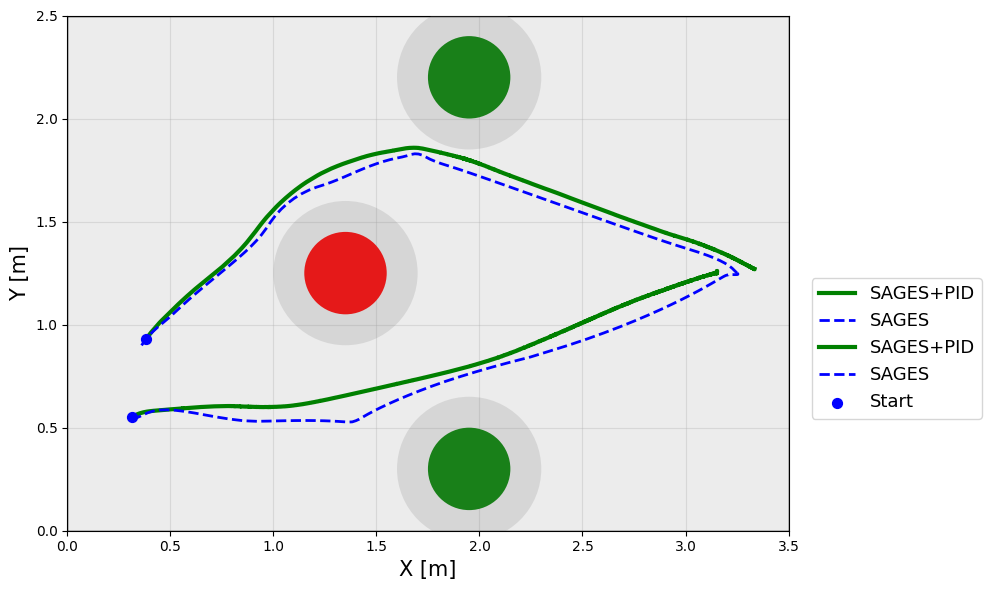

In [19]:
def ff_plot(state, goal):
    fig, ax = plt.subplots(figsize=(10,6))
    _plot_environment(ax)
    

    ax.plot(state['x'], state['y'], color = 'g',  linewidth=3,  label='SAGES+PID', zorder=3)
    ax.plot(goal['x'], goal['y'], color = 'b', linestyle = '--',linewidth=2.0, label='SAGES', zorder=3)

    ax.plot(state_l['x'], state_l['y'], color = 'g',  linewidth=3,  label='SAGES+PID', zorder=3)
    ax.plot(goal_l['x'], goal_l['y'], color = 'b', linestyle = '--',linewidth=2.0, label='SAGES', zorder=3)

    ax.scatter(state_l['x'][0], state_l['y'][0], s=50, marker='o', c='blue', label='Start', zorder=5)
    ax.scatter(state['x'][0], state['y'][0], s=50, marker='o', c='blue', label=None, zorder=5)
    ax.grid(True)
    ax.set_aspect('equal')
    ax.set_xlabel('X [m]', fontsize=15)
    ax.set_ylabel('Y [m]', fontsize=15)
    ax.grid(True)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels,
            loc='lower center',
            ncol=1,
            bbox_to_anchor=(1.15, 0.2), # (0.5, -0.45)
            fontsize=13)
    plt.tight_layout()
    plt.show()

ff_plot(state, goal)

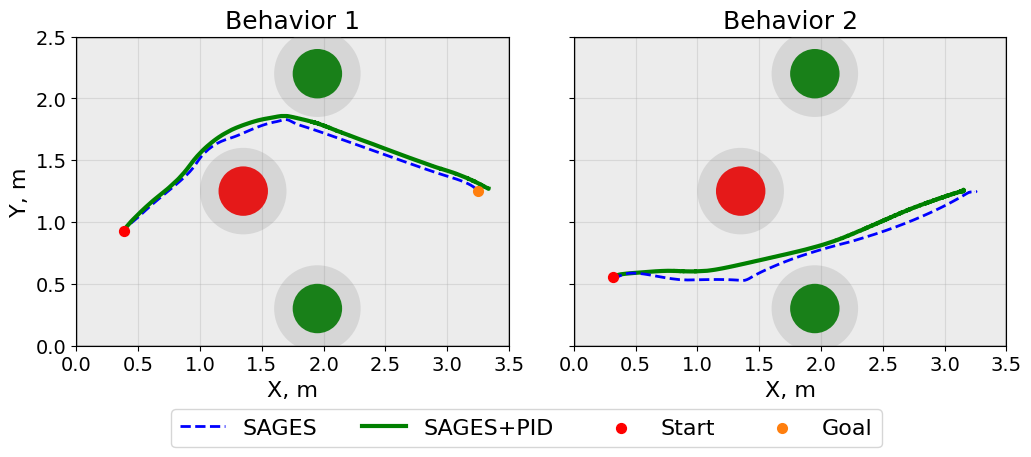

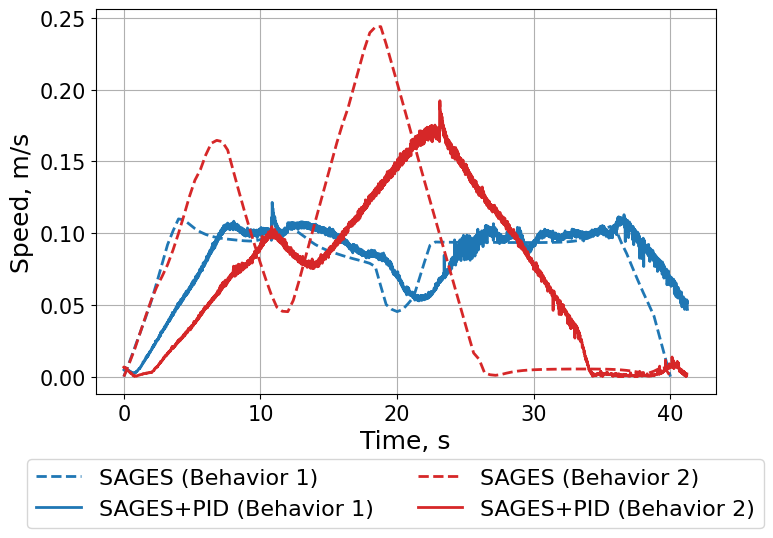

In [22]:


def ff_plot_two(state1, goal1, state2, goal2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))  # 1×2 layout
    ax1, ax2 = axes

    # ----------------------------
    # Subplot 1
    # ----------------------------
    _plot_environment(ax1)

    ax2.plot(state1['x'], state1['y'], color='g', linewidth=3, label='SAGES+PID', zorder=3)
    ax2.plot(goal1['x'], goal1['y'], color='b', linestyle='--', linewidth=2.0, label='SAGES', zorder=3)

    ax2.scatter(state1['x'][0], state1['y'][0], s=50, marker='o', c='r', label='Start', zorder=5)

    ax2.set_aspect('equal')
    ax2.set_xlabel('X, m', fontsize=16)
    # ax2.set_ylabel('Y, m', fontsize=16)
    ax2.set_title("Behavior 2", fontsize=18)
    ax2.tick_params(axis='both', labelsize=14)
    ax2.grid(True)
    ax2.set_xticks([0,0.5,1.0,1.5,2.0,2.5,3.0,3.5])  # Hide x tick labels for top subplot

    # ----------------------------
    # Subplot 2
    # ----------------------------
    _plot_environment(ax2)

    ax1.plot(goal2['x'], goal2['y'], color='b', linestyle='--', linewidth=2.0, label='SAGES', zorder=3)
    ax1.plot(state2['x'], state2['y'], color='g', linewidth=3, label='SAGES+PID', zorder=3)

    ax1.scatter(state2['x'][0], state2['y'][0], s=50, marker='o', c='r', label='Start', zorder=5)
    ax1.scatter(goal2['x'][-1], goal2['y'][-1], color='C1', linewidth=2.0, label='Goal', zorder=3)

    ax1.set_aspect('equal')
    ax1.set_xlabel('X, m', fontsize=16)
    ax1.set_ylabel('Y, m', fontsize=16)
    ax1.set_title("Behavior 1", fontsize=18)
    ax1.tick_params(axis='both', labelsize=14)
    ax1.grid(True)
    ax2.set_yticklabels([])
    ax1.set_xticks([0,0.5,1.0,1.5,2.0,2.5,3.0,3.5])  # Hide x tick labels for top subplot

    # ----------------------------
    # Shared Legend
    # ----------------------------
    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='lower center',
               ncol=4,
               bbox_to_anchor=(0.5, 0.05),
               fontsize=16)
    fig.subplots_adjust(wspace=0.15)
    
    plt.show()

ff_plot_two(state, goal, state_l, goal_l)

from cvxpy import pos


def plot_speed_mag(state, goal, state_l, goal_l):

    fig, ax = plt.subplots(figsize=(8, 5))

    # ---- Compute speed magnitudes ----
    speed_1_real = np.sqrt(state['vx']**2 + state['vy']**2)
    speed_1_ref  = np.sqrt(goal['vx']**2 + goal['vy']**2)

    speed_2_real = np.sqrt(state_l['vx']**2 + state_l['vy']**2)
    speed_2_ref  = np.sqrt(goal_l['vx']**2 + goal_l['vy']**2)

    # ---- Plot ----
    ax.plot(goal_l['time'],  speed_2_ref,  'C0--', linewidth=2, label='SAGES (Behavior 1)')
    ax.plot(state_l['time'], speed_2_real, 'C0-',  linewidth=2, label='SAGES+PID (Behavior 1)')

    ax.plot(goal['time'],  speed_1_ref,  'C3--', linewidth=2, label='SAGES (Behavior 2)')
    ax.plot(state['time'], speed_1_real, 'C3-',  linewidth=2, label='SAGES+PID (Behavior 2)')

    # ---- Style ----
    ax.set_xlabel("Time, s", fontsize=18)
    ax.set_ylabel("Speed, m/s", fontsize=18)
     # >>> Add this line for tick font size <<<
    ax.tick_params(axis='both', labelsize=15)
    
    ax.grid(True)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels,
               loc='lower center',
               ncol=2,
               bbox_to_anchor=(0.5, 0.0),
               fontsize=16)
    pos = ax.get_position()
    ax.set_position([pos.x0, pos.y0 + 0.18, pos.width, pos.height])

    # plt.tight_layout()
   
    plt.show()

plot_speed_mag(state, goal, state_l, goal_l)

In [5]:
from scipy.interpolate import interp1d
def eval_RMSE(state, goal, onlypos=False):
    tt = np.arange(goal['time'][0], 51, 0.01)
    if onlypos:
        f_goal = interp1d(goal['time'], np.vstack((goal['x'], goal['y'])), bounds_error=False, fill_value=np.vstack((goal['x'], goal['y']))[:,-1])
        f_state = interp1d(state['time'], np.vstack((state['x'], state['y'])), fill_value="extrapolate")
    else:
        f_goal = interp1d(goal['time'], np.vstack((goal['x'], goal['y'], goal['psi'], goal['vx'], goal['vy'], goal['wz'])), bounds_error=False, fill_value=np.vstack((goal['x'], goal['y'], goal['psi'], goal['vx'], goal['vy'], goal['wz']))[:,-1])
        f_state = interp1d(state['time'], np.vstack((state['x'], state['y'], state['psi'], state['vx'], state['vy'], state['wz'])), fill_value="extrapolate")
    interp_state = f_state(tt)
    interp_goal = f_goal(tt)
    return np.linalg.norm(interp_goal - interp_state, axis=0).mean()

In [6]:
import copy
def compute_consumption(action):
    tt = action['time']
    switches = action['switches']

    T_ON = np.zeros((switches.shape[0],))
    for i in range(switches.shape[0]):
        mask = switches[i,:-1]
        dts = tt[1:] - tt[:-1]
        T_ON[i] = np.sum(dts[mask])
    
    return T_ON

def cut_times(list_msg, last_index):
    list_out = []
    for msg in list_msg:
        mask = msg['time'] <= last_index
        msg = copy.deepcopy(msg)
        for key in msg.keys():
            if key == 'switches':
                msg[key] = msg[key][:,mask]
            else:
                msg[key] = msg[key][mask]
        list_out.append(msg)

    return list_out


def performances_analysis(state_list, goal_list, action_list, case_list, final_times_list=None):
    n_case = len(case_list)
    mosaic = [['pos'+str(n) for n in range(n_case)],
              ['vel'+str(n) for n in range(n_case)],
              ['act'+str(n) for n in range(n_case)],
              ['act'+str(n) for n in range(n_case)],
              ['act'+str(n) for n in range(n_case)]]
    if final_times_list is None:
        final_times_list = 40.0*np.ones((n_case,))
    else:
        final_times_list = np.array(final_times_list)
    last_index_list = (1.25*final_times_list).astype(int)
    fig,ax = plt.subplot_mosaic(mosaic, figsize=(20,20))#subplots(4,n_case,figsize=(20,10))
    for n, (state, goal, action, case, last_index) in enumerate(zip(state_list, goal_list, action_list, case_list, last_index_list)):
        state, goal, action = cut_times((state, goal, action), last_index)
        for i in range(2):
            state2show = ['x','y'] if i==0 else ['vx','vy']
            for j in range(len(state2show)):
                ax[mosaic[i][n]].plot(state['time'], state[state2show[j]], linewidth=2, label=state2show[j]+'_state_'+case)
                ax[mosaic[i][n]].plot(goal['time'], goal[state2show[j]], linewidth=2, label=state2show[j]+'_goal_'+case)
                ax[mosaic[i][n]].grid(True)
                ax[mosaic[i][n]].set_ylabel('Position [m]' if i==0 else 'Velocity [m/s]')
                ax[mosaic[i][n]].legend(loc='best')
        
        T_ON = compute_consumption(action)
        for i in range(action['switches'].shape[0]):
            #ax['act'+str(n)].stem(action['time'], i+action['switches'][i]/2, linefmt='C'+str(i), markerfmt='C'+str(i)+'o', bottom = i)
            ax['act'+str(n)].stem(action['time'], i+action['switches'][i]/2, linefmt='C'+str(i), markerfmt='C'+str(i)+'o', bottom = i)
            ax['act'+str(n)].text(-1.5, i+0.15, str(np.round(T_ON[i],2)), rotation='vertical')
        ax['act'+str(n)].set_title('Total firing time: '+str(np.round(T_ON.sum(),2))+' s')
        ax['act'+str(n)].set_ylabel('Thrustes [ON/OFF]')
        ax['act'+str(n)].set_xlabel('Time [s]')
        ax['act'+str(n)].grid(True)
    plt.show()

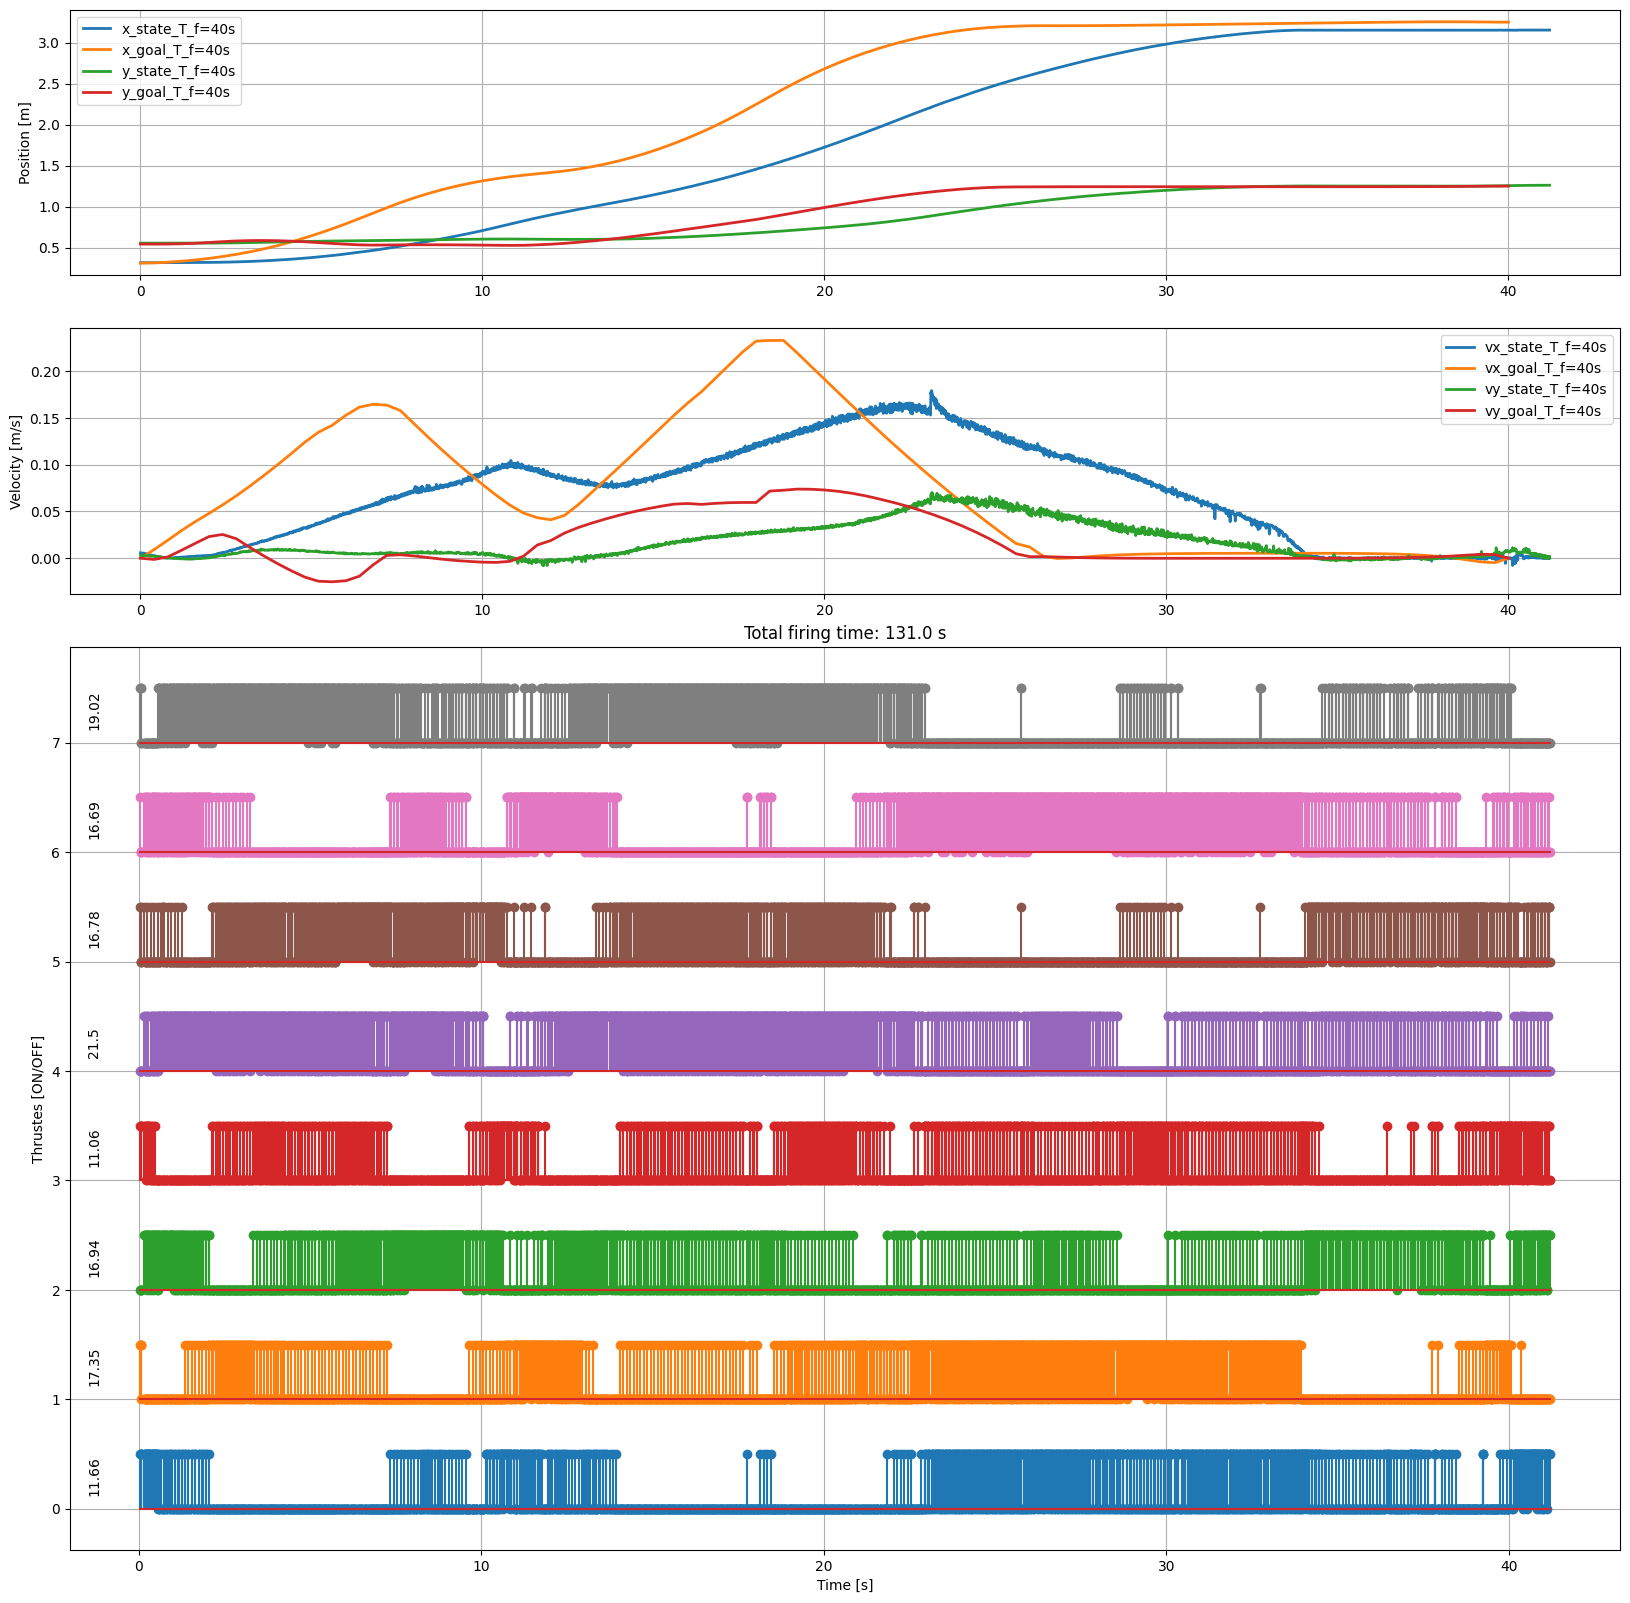

In [7]:
performances_analysis([state], [goal], [action], ['T_f=40s'], [40])

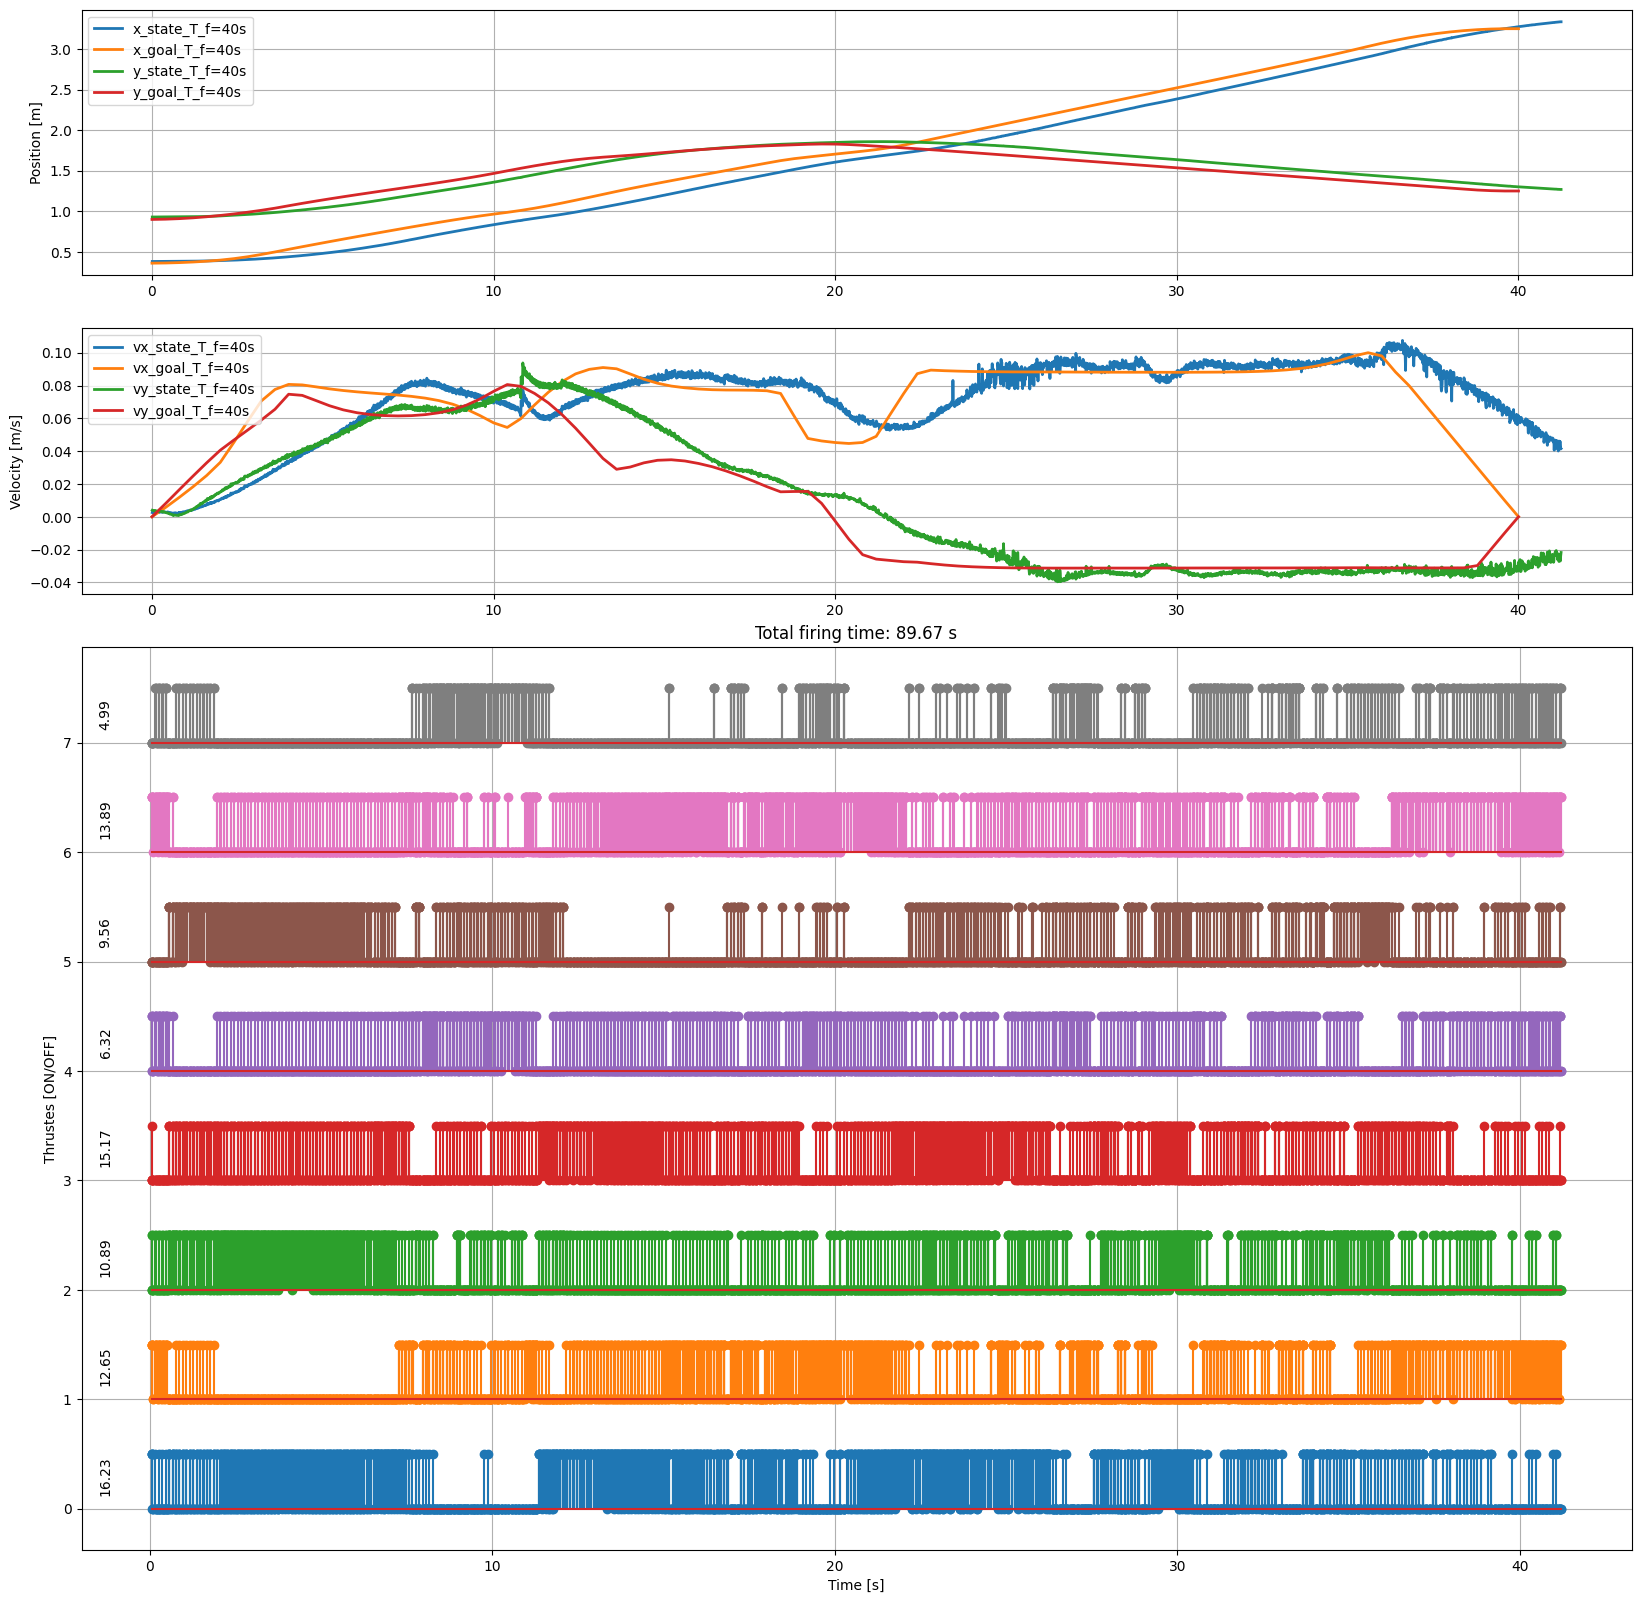

In [7]:
performances_analysis([state_l], [goal_l], [action_l], ['T_f=40s'], [40])

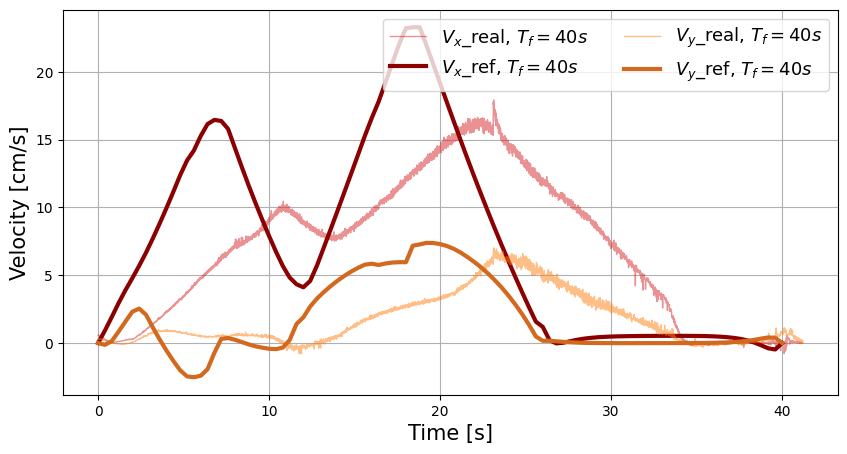

In [8]:
fig,ax = plt.subplots(figsize=(10,5))#subplots(4,n_case,figsize=(20,10))
for n, (state, goal, case) in enumerate(zip([state], [goal],  ['$T_f=40s$'])):
    state2show = ['vx','vy']
    statelabel = ['$V_x$', '$V_y$']
    colors = [[['C3', 'darkred'], ['C1', 'chocolate']],
              [['C0', 'darkblue'], ['C2', 'darkgreen']]]
    for j in range(len(state2show)):
        ax.plot(state['time'], 100*state[state2show[j]], colors[n][j][0], alpha=0.5, linewidth=1, label=statelabel[j]+'_real, '+case)
        ax.plot(goal['time'], 100*goal[state2show[j]], colors[n][j][1], linewidth=3, label=statelabel[j]+'_ref, '+case)
        ax.grid(True)
        ax.set_ylabel('Velocity [cm/s]', fontsize=15)
        ax.set_xlabel('Time [s]', fontsize=15)
        # ax.set_ylim([-2.5, 20.5])
        ax.legend(loc='best', ncols=2, fontsize=13)
plt.show()